# Vendi Score Approximation Methods: Implementation & Benchmarks

Tests Methods 1–3 & 5 from `vendi_score_active_learning.md` against exact `torch.linalg.eigvalsh`.

**Experiment 1** — standalone Vendi score on a 2000×2000 trace-normalized matrix: Randomized SVD vs Nyström.  
**Experiment 2** — active-learning per-candidate scoring: Naive (eigvalsh) vs Secular Equation vs Randomized SVD vs Residual Surrogate.

In [1]:
import numpy as np
import torch
import time
from scipy.optimize import brentq
from sklearn.utils.extmath import randomized_svd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

np.random.seed(42)
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Helper utilities

In [13]:
def vendi_from_lam(lam: np.ndarray) -> float:
    """Vendi score from eigenvalues. Normalises internally."""
    lam = np.asarray(lam, dtype=float)
    lam = lam[lam > 0]
    if len(lam) == 0:
        return 1.0
    lam = lam / lam.sum()
    return float(np.exp(-np.sum(lam * np.log(lam))))


class Timer:
    def __enter__(self):
        self._t = time.perf_counter()
        return self
    def __exit__(self, *_):
        self.elapsed = time.perf_counter() - self._t

## Data generation

In [ ]:
def make_kernel(n, d=64, seed=0, sigma=1.0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d)) # embeddings
    # RBF kernel
    dists = np.sum((X[:, None] - X[None, :]) ** 2, axis=-1)
    K = np.exp(-dists / (2 * sigma**2))
    K /= np.trace(K)
    return K.astype(np.float64)



def make_embeddings(n: int, d: int = 64, seed: int = 0) -> np.ndarray:
    """Unit-normalised embeddings (n, d) for cosine-kernel AL experiment."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d))
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X.astype(np.float64)

## Approximation methods

In [14]:
# ------------------------------------------------------------------
# Exact baseline  (torch.linalg.eigvalsh)
# ------------------------------------------------------------------
def exact_vendi(K: np.ndarray):
    """Returns (vendi_score, elapsed_s). Uses torch.linalg.eigvalsh."""
    K_t = torch.tensor(K, dtype=torch.float64, device=device)
    if device == 'cuda':
        torch.cuda.synchronize()
    with Timer() as tmr:
        lam = torch.linalg.eigvalsh(K_t).cpu().numpy()
        if device == 'cuda':
            torch.cuda.synchronize()
    return lam, vendi_from_lam(lam), tmr.elapsed

In [5]:
# ------------------------------------------------------------------
# Method 2: Randomized SVD
# ------------------------------------------------------------------
def randomized_vendi(K: np.ndarray, k: int = 100, n_iter: int = 4):
    """
    Approximate Vendi score via top-k randomized SVD.
    For PSD K: singular values == eigenvalues.
    Remaining mass (1 - sum(top-k)) is bundled as one extra eigenvalue.
    """
    with Timer() as tmr:
        _, s, _ = randomized_svd(K, n_components=k, n_iter=n_iter, random_state=42)
        residual = max(1.0 - s.sum(), 0.0)
        lam = np.append(s, residual) if residual > 1e-12 else s
        vs = vendi_from_lam(lam)
    return vs, tmr.elapsed

In [6]:
# ------------------------------------------------------------------
# Method 1: Nyström approximation
# ------------------------------------------------------------------
def nystrom_vendi(K: np.ndarray, m: int = 100, seed: int = 0):
    """
    Approximate top eigenvalues of K via Nyström with m landmark points.
    K ≈ C W^{-1} C^T  →  eigenvalues of W^{-1/2} C^T C W^{-1/2}  (m×m problem).
    """
    with Timer() as tmr:
        n = K.shape[0]
        idx = np.random.default_rng(seed).choice(n, size=m, replace=False)

        W = K[np.ix_(idx, idx)]          # m×m
        C = K[:, idx]                    # n×m

        lam_w, V_w = np.linalg.eigh(W + 1e-10 * np.eye(m))
        lam_w = np.maximum(lam_w, 1e-12)
        W_inv_sqrt = V_w @ np.diag(1.0 / np.sqrt(lam_w)) @ V_w.T

        B = W_inv_sqrt @ C.T             # m×n
        M_hat = B @ B.T                  # m×m: shares nonzero eigenvalues with C W^{-1} C^T

        lam_m = np.linalg.eigvalsh(M_hat)
        vs = vendi_from_lam(lam_m)       # vendi_from_lam normalises internally
    return vs, tmr.elapsed

In [7]:
# ------------------------------------------------------------------
# Method 3: Secular equation rank-1 update  (for AL per-candidate)
# ------------------------------------------------------------------
def precompute_eigen(K_L: np.ndarray):
    """
    Eigendecompose K_L once per AL iteration.
    K_L is the *unnormalised* labeled-set kernel (trace = n_L, diagonal = 1).
    Returns (eigenvalues ascending, eigenvectors, elapsed_s).
    """
    with Timer() as tmr:
        lam, Q = np.linalg.eigh(K_L)
    return lam, Q, tmr.elapsed


def _secular_roots(lam: np.ndarray, d: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Solve  f(μ) = 1 - μ - Σ d_i² / (λ_i - μ) = 0.

    By Cauchy interlacing there is exactly one root in each of the n+1 intervals:
      (-∞, λ_1), (λ_1, λ_2), ..., (λ_{n-1}, λ_n), (λ_n, +∞).
    """
    n = len(lam)
    d2 = d ** 2
    d2_sum = float(d2.sum())

    def f(mu: float) -> float:
        den = lam - mu
        den = np.where(np.abs(den) < eps, np.sign(den + 1e-300) * eps, den)
        return 1.0 - mu - float(np.sum(d2 / den))

    roots = []

    # Root below λ_1
    try:
        roots.append(brentq(f, lam[0] - d2_sum - 1.0, lam[0] - eps,
                            xtol=1e-10, maxiter=200))
    except ValueError:
        roots.append(float(lam[0]))

    # n-1 interior roots in (λ_i, λ_{i+1})
    for i in range(n - 1):
        lo, hi = lam[i] + eps, lam[i + 1] - eps
        if lo >= hi:
            roots.append(float((lam[i] + lam[i + 1]) / 2))
            continue
        try:
            roots.append(brentq(f, lo, hi, xtol=1e-10, maxiter=200))
        except ValueError:
            roots.append(float(lam[i]))

    # Root above λ_n
    try:
        roots.append(brentq(f, lam[-1] + eps, lam[-1] + d2_sum + 1.0,
                            xtol=1e-10, maxiter=200))
    except ValueError:
        roots.append(float(lam[-1]))

    return np.array(roots)


def secular_vendi(lam: np.ndarray, Q: np.ndarray, k_u: np.ndarray) -> float:
    """
    VS(L ∪ {u}) via secular equation rank-1 update.

    Args:
        lam  : eigenvalues of K_L (ascending), shape (n_L,)
        Q    : eigenvectors of K_L, shape (n_L, n_L)
        k_u  : kernel vector k(L, u), shape (n_L,)  [k(u,u)=1 implied]
    """
    n = len(lam)
    d = Q.T @ k_u                   # project into K_L eigenbasis
    mu = _secular_roots(lam, d)     # n+1 eigenvalues of K_{L∪{u}}
    return vendi_from_lam(mu / (n + 1))

In [ ]:
# # ------------------------------------------------------------------
# # Method 5: Residual norm surrogate  (for AL per-candidate)
# # ------------------------------------------------------------------
# def precompute_topk(K_L: np.ndarray, k: int) -> np.ndarray:
#     """Top-k eigenvectors of K_L (eigh returns ascending order)."""
#     _, Q = np.linalg.eigh(K_L)
#     return Q[:, -k:]  # (n_L, k)


# def residual_surrogate(Q_topk: np.ndarray, k_u: np.ndarray) -> float:
#     """
#     Fast diversity proxy: 1 - ||Q_k^T k_u||^2.
#     Higher → more out-of-eigenspace → more diverse.
#     Not equal to Vendi score; correlates with VS gain.
#     """
#     proj = Q_topk.T @ k_u
#     return float(1.0 - np.dot(proj, proj))

---
## Experiment 1 — Standalone Vendi score on a 2000×2000 matrix

Sweep rank/landmarks for Randomized SVD and Nyström; compare timing and error against `torch.linalg.eigvalsh`.

In [15]:
n = 2000
print(f'Generating {n}×{n} kernel matrix (trace=1)...')
K2000 = make_kernel(n, d=128, seed=42)
print(f'Trace = {K2000.trace():.6f}  \
      max_eig = {np.linalg.eigvalsh(K2000[:100,:100]).max():.2e} \
      min_eig = {np.linalg.eigvalsh(K2000[:100,:100]).min():.2e}')

print('\nExact baseline (torch.linalg.eigvalsh)...')
lam, vs_exact, t_exact = exact_vendi(K2000)
print(f'  VS = {vs_exact:.6f}   time = {t_exact:.4f}s')

Generating 2000×2000 kernel matrix (trace=1)...
Trace = 1.000000        max_eig = 5.00e-04       min_eig = 5.00e-04

Exact baseline (torch.linalg.eigvalsh)...
  VS = 2000.000000   time = 0.0400s


In [17]:
vs_exact

1999.9999999999961

In [18]:
# Randomized SVD sweep
k_vals = [10, 20, 50, 100, 200, 500, 1000, 1500]
rows_rsvd = []
print('Randomized SVD (n_iter=4):')
for k in k_vals:
    vs, t = randomized_vendi(K2000, k=k, n_iter=4)
    err = abs(vs - vs_exact)
    rows_rsvd.append({'k': k, 'VS': vs, 'Abs Error': err,
                       'Rel Error': err / vs_exact, 'Time (s)': t})
    print(f'  k={k:4d}  VS={vs:.6f}  |err|={err:.3e}  t={t:.4f}s')

df_rsvd = pd.DataFrame(rows_rsvd)

Randomized SVD (n_iter=4):
  k=  10  VS=1.043930  |err|=1.999e+03  t=0.0573s
  k=  20  VS=1.089761  |err|=1.999e+03  t=0.0691s
  k=  50  VS=1.239499  |err|=1.999e+03  t=0.4030s
  k= 100  VS=1.535374  |err|=1.998e+03  t=0.6560s
  k= 200  VS=2.351174  |err|=1.998e+03  t=1.0380s
  k= 500  VS=8.297773  |err|=1.992e+03  t=1.2378s
  k=1000  VS=63.245553  |err|=1.937e+03  t=1.7437s
  k=1500  VS=422.948505  |err|=1.577e+03  t=2.2197s


In [19]:
# Nyström sweep
m_vals = [20, 50, 100, 200, 500]
rows_nys = []
print('Nyström approximation:')
for m in m_vals:
    vs, t = nystrom_vendi(K2000, m=m, seed=0)
    err = abs(vs - vs_exact)
    rows_nys.append({'m': m, 'VS': vs, 'Abs Error': err,
                      'Rel Error': err / vs_exact, 'Time (s)': t})
    print(f'  m={m:4d}  VS={vs:.6f}  |err|={err:.3e}  t={t:.4f}s')

df_nys = pd.DataFrame(rows_nys)

Nyström approximation:
  m=  20  VS=20.000000  |err|=1.980e+03  t=0.0013s
  m=  50  VS=50.000000  |err|=1.950e+03  t=0.0017s
  m= 100  VS=100.000000  |err|=1.900e+03  t=0.0052s
  m= 200  VS=200.000000  |err|=1.800e+03  t=0.0162s
  m= 500  VS=500.000000  |err|=1.500e+03  t=0.7296s


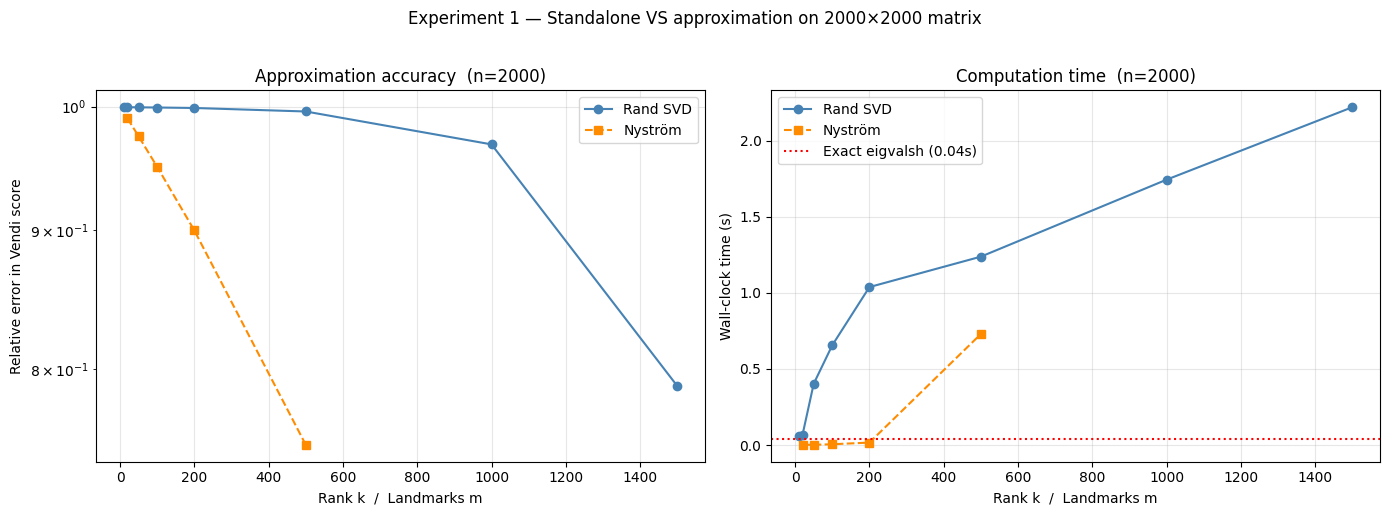

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(df_rsvd['k'], df_rsvd['Rel Error'], 'o-', color='steelblue', label='Rand SVD')
ax.semilogy(df_nys['m'],  df_nys['Rel Error'],  's--', color='darkorange', label='Nyström')
ax.set_xlabel('Rank k  /  Landmarks m')
ax.set_ylabel('Relative error in Vendi score')
ax.set_title(f'Approximation accuracy  (n={n})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_rsvd['k'], df_rsvd['Time (s)'], 'o-', color='steelblue', label='Rand SVD')
ax.plot(df_nys['m'],  df_nys['Time (s)'],  's--', color='darkorange', label='Nyström')
ax.axhline(t_exact, color='red', linestyle=':', linewidth=1.5,
           label=f'Exact eigvalsh ({t_exact:.2f}s)')
ax.set_xlabel('Rank k  /  Landmarks m')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title(f'Computation time  (n={n})')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 1 — Standalone VS approximation on 2000×2000 matrix', y=1.02)
plt.tight_layout()
plt.savefig('exp1_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table — Experiment 1
row_exact = pd.DataFrame([{'Method': 'Exact (torch.eigvalsh)', 'Rank': n,
                            'VS': vs_exact, 'Rel Error': 0.0, 'Time (s)': t_exact}])
rsvd_disp = df_rsvd.copy()
rsvd_disp['Method'] = rsvd_disp['k'].apply(lambda x: f'Rand SVD k={x}')
rsvd_disp.rename(columns={'k': 'Rank'}, inplace=True)

nys_disp = df_nys.copy()
nys_disp['Method'] = nys_disp['m'].apply(lambda x: f'Nyström m={x}')
nys_disp.rename(columns={'m': 'Rank'}, inplace=True)

cols = ['Method', 'Rank', 'VS', 'Rel Error', 'Time (s)']
df_exp1 = pd.concat([row_exact, rsvd_disp[cols], nys_disp[cols]], ignore_index=True)
display(df_exp1.to_string(index=False, float_format='{:.4e}'.format))

---
## Experiment 2 — Active-learning per-candidate scoring

**Setup:** n_L labeled points, n_U candidates.  
Ground truth = `torch.linalg.eigvalsh` on the full (n_L+1)×(n_L+1) augmented matrix per candidate.  
Compared against: Secular Equation, Randomized SVD per-candidate, Residual Surrogate.

> Secular equation note: pure-Python brentq is O(n_L²) per candidate. n_L=300 keeps wall-clock under ~10s for 100 candidates.

In [38]:
n_L   = 300    # labeled set size
n_U   = 100    # number of AL candidates
d     = 64
sigma = 1.0    # RBF bandwidth

def rbf_kernel(A, B, sigma=1.0):
    """RBF kernel matrix between rows of A (n,d) and B (m,d). Returns (n,m)."""
    if sigma is None:
        sigma = np.sqrt(A.shape[0])
    dists = np.sum((A[:, None] - B[None, :]) ** 2, axis=-1)
    return np.exp(-dists / (2 * sigma**2))

rng   = np.random.default_rng(1)
X_all = rng.standard_normal((n_L + n_U, d))
X_L   = X_all[:n_L]    # (n_L, d)
X_U   = X_all[n_L:]    # (n_U, d)

# RBF kernel matrices (diagonal = 1, so trace(K_LL) = n_L)
K_LL = rbf_kernel(X_L, X_L, sigma=None)   # (n_L, n_L)
K_LU = rbf_kernel(X_L, X_U, sigma=None)   # (n_L, n_U)
K_LL = torch.tensor(K_LL)
K_LU = torch.tensor(K_LU)

print(f'n_L={n_L}  n_U={n_U}  d={d}  sigma={sigma}')
print(f'K_LL trace = {K_LL.trace():.1f}  (expected = {n_L})')

n_L=300  n_U=100  d=64  sigma=1.0
K_LL trace = 300.0  (expected = 300)


In [40]:
# Ground truth: eigvalsh on full (n_L+1)×(n_L+1) augmented matrix per candidate
print('Ground truth (torch.eigvalsh per candidate)...')
vs_gt   = np.zeros(n_U)
t_naive = 0.0
K_aug = torch.zeros(n_L + 1, n_L + 1)
K_aug[:n_L, :n_L] = K_LL
K_aug[n_L, n_L] = 1.0
for i in range(n_U):
    k_u = K_LU[:, i]
    K_aug[n_L, :-1] = K_aug[:-1, n_L] = k_u
    with Timer() as tmr:
        lam = torch.linalg.eigvalsh(K_aug).cpu().numpy()
    t_naive  += tmr.elapsed
    vs_gt[i]  = vendi_from_lam(lam / (n_L + 1))
print(f'  Total time: {t_naive:.4f}s  (avg {t_naive/n_U*1e3:.1f}ms/candidate)')
print(f'  VS range: [{vs_gt.min():.12f}, {vs_gt.max():.12f}]')
        

Ground truth (torch.eigvalsh per candidate)...
  Total time: 1.0875s  (avg 10.9ms/candidate)
  VS range: [3.742917198566, 3.753171324117]


In [41]:
# Secular equation
print('Secular equation (rank-1 update)...')
lam_L, Q_L, t_setup = precompute_eigen(K_LL)
print(f'  Eigendecomposition: {t_setup:.4f}s')

vs_sec = np.zeros(n_U)
t_sec_cands = 0.0

for i in range(n_U):
    with Timer() as tmr:
        vs_sec[i] = secular_vendi(lam_L, Q_L, K_LU[:, i])
    t_sec_cands += tmr.elapsed

t_sec_total = t_setup + t_sec_cands
print(f'  Candidate scoring: {t_sec_cands:.4f}s  (avg {t_sec_cands/n_U*1e3:.1f}ms/candidate)')
print(f'  Total (setup + scoring): {t_sec_total:.4f}s')
print(f'  MAE = {np.abs(vs_sec - vs_gt).mean():.3e}   max = {np.abs(vs_sec - vs_gt).max():.3e}')

Secular equation (rank-1 update)...
  Eigendecomposition: 0.0132s


TypeError: unsupported operand type(s) for @: 'numpy.ndarray' and 'Tensor'

In [ ]:
# Randomized SVD per candidate
k_rsvd_al = 40
print(f'Randomized SVD per candidate (k={k_rsvd_al})...')

vs_rsvd_al = np.zeros(n_U)
t_rsvd_al  = 0.0

for i in range(n_U):
    k_u   = K_LU[:, i]
    K_aug = np.block([[K_LL,             k_u[:, None]],
                      [k_u[None, :],     [[1.0]]]])
    with Timer() as tmr:
        _, s, _ = randomized_svd(K_aug, n_components=k_rsvd_al, n_iter=2, random_state=0)
        # K_aug is unnormalised; divide by (n_L+1) to get probabilities
        lam = s / (n_L + 1)
        residual = max(1.0 - lam.sum(), 0.0)
        lam = np.append(lam, residual) if residual > 1e-12 else lam
        vs_rsvd_al[i] = vendi_from_lam(lam)
    t_rsvd_al += tmr.elapsed

print(f'  Total: {t_rsvd_al:.4f}s  (avg {t_rsvd_al/n_U*1e3:.1f}ms/candidate)')
print(f'  MAE = {np.abs(vs_rsvd_al - vs_gt).mean():.3e}   max = {np.abs(vs_rsvd_al - vs_gt).max():.3e}')

In [ ]:
# Residual norm surrogate
k_top = 40
print(f'Residual norm surrogate (top-{k_top} eigenvectors)...')
with Timer() as tmr_setup_res:
    Q_topk = precompute_topk(K_LL, k=k_top)

residuals = np.zeros(n_U)
with Timer() as tmr_res:
    for i in range(n_U):
        residuals[i] = residual_surrogate(Q_topk, K_LU[:, i])

t_res_total = tmr_setup_res.elapsed + tmr_res.elapsed
rank_corr   = float(np.corrcoef(residuals, vs_gt)[0, 1])
print(f'  Setup: {tmr_setup_res.elapsed:.4f}s   scoring: {tmr_res.elapsed:.4f}s')
print(f'  Total: {t_res_total:.4f}s')
print(f'  Rank correlation with exact VS: {rank_corr:.4f}')
print('  (Not VS — MAE is not meaningful; rank correlation is the right metric)')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
idx = np.arange(n_U)

# VS per candidate
ax = axes[0]
ax.plot(idx, vs_gt,      'k-',  lw=1.5, label='Exact (eigvalsh)')
ax.plot(idx, vs_sec,     'b--', lw=1.2, alpha=0.85, label='Secular eq.')
ax.plot(idx, vs_rsvd_al, 'r:',  lw=1.2, alpha=0.85, label=f'Rand SVD k={k_rsvd_al}')
ax.set_xlabel('Candidate index')
ax.set_ylabel('Vendi score VS(L ∪ {u})')
ax.set_title(f'VS per candidate  (n_L={n_L})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Absolute error
ax = axes[1]
ax.semilogy(idx, np.abs(vs_sec     - vs_gt) + 1e-16, 'b--', lw=1.2, label='Secular eq.')
ax.semilogy(idx, np.abs(vs_rsvd_al - vs_gt) + 1e-16, 'r:',  lw=1.2, label=f'Rand SVD k={k_rsvd_al}')
ax.set_xlabel('Candidate index')
ax.set_ylabel('|VS_approx − VS_exact|')
ax.set_title('Absolute error per candidate')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Timing comparison
ax = axes[2]
methods = ['Naive\n(eigvalsh)', 'Secular eq.\n(setup+all)', f'Rand SVD\n(k={k_rsvd_al})', f'Residual\n(k={k_top})']
times   = [t_naive, t_sec_total, t_rsvd_al, t_res_total]
colors  = ['#c0392b', '#2980b9', '#e67e22', '#27ae60']
bars = ax.bar(methods, times, color=colors, edgecolor='black', alpha=0.85)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(times)*0.015,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Total time (s)')
ax.set_title(f'Timing ({n_U} candidates)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Experiment 2 — AL per-candidate VS  (n_L={n_L}, |U|={n_U})', y=1.02)
plt.tight_layout()
plt.savefig('exp2_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Residual surrogate vs exact VS scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(vs_gt, residuals, alpha=0.6, edgecolors='k', linewidths=0.4)
ax.set_xlabel('Exact VS(L ∪ {u})')
ax.set_ylabel('Residual surrogate  1 − ||Q_k^T k_u||²')
ax.set_title(f'Surrogate vs exact VS  (rank corr = {rank_corr:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table — Experiment 2
df_exp2 = pd.DataFrame([
    {'Method': 'Naive (torch.eigvalsh)',
     'Total Time (s)': t_naive,
     'Avg ms/cand':   t_naive / n_U * 1e3,
     'MAE':   0.0,   'Max Err': 0.0,  'Note': 'ground truth'},
    {'Method': 'Secular equation',
     'Total Time (s)': t_sec_total,
     'Avg ms/cand':    t_sec_cands / n_U * 1e3,
     'MAE':   np.abs(vs_sec - vs_gt).mean(),
     'Max Err': np.abs(vs_sec - vs_gt).max(),
     'Note': 'exact VS (numerical)'},
    {'Method': f'Rand SVD k={k_rsvd_al}',
     'Total Time (s)': t_rsvd_al,
     'Avg ms/cand':    t_rsvd_al / n_U * 1e3,
     'MAE':   np.abs(vs_rsvd_al - vs_gt).mean(),
     'Max Err': np.abs(vs_rsvd_al - vs_gt).max(),
     'Note': 'approx VS'},
    {'Method': f'Residual surrogate k={k_top}',
     'Total Time (s)': t_res_total,
     'Avg ms/cand':    tmr_res.elapsed / n_U * 1e3,
     'MAE':   float('nan'), 'Max Err': float('nan'),
     'Note': f'proxy only; rank_corr={rank_corr:.4f}'},
])
display(df_exp2)

---
## Experiment 3 — Scaling: secular equation vs naive across matrix sizes

Measures wall-clock time for scoring **10 candidates** as n_L grows from 50 → 1000.

In [ ]:
sizes  = [50, 100, 200, 300, 500, 750, 1000]
n_cands_scale = 10    # small enough to keep naive feasible at n=1000
rows_scale = []

for nl in sizes:
    X_sc   = make_embeddings(nl + n_cands_scale, d=64, seed=99)
    K_sc   = X_sc[:nl] @ X_sc[:nl].T
    K_lu   = X_sc[:nl] @ X_sc[nl:].T

    # Naive
    t_n = 0.0
    for i in range(n_cands_scale):
        k_u   = K_lu[:, i]
        K_aug = np.block([[K_sc, k_u[:, None]], [k_u[None, :], [[1.0]]]])
        with Timer() as tmr:
            torch.linalg.eigvalsh(torch.tensor(K_aug, dtype=torch.float64, device=device))
        t_n += tmr.elapsed

    # Secular
    lam_sc, Q_sc, t_s_setup = precompute_eigen(K_sc)
    t_s = t_s_setup
    for i in range(n_cands_scale):
        with Timer() as tmr:
            secular_vendi(lam_sc, Q_sc, K_lu[:, i])
        t_s += tmr.elapsed

    rows_scale.append({'n_L': nl, 'Naive (s)': t_n, 'Secular (s)': t_s,
                        'Speedup': t_n / t_s})
    print(f'n_L={nl:5d}  naive={t_n:.4f}s  secular={t_s:.4f}s  speedup={t_n/t_s:.2f}x')

df_scale = pd.DataFrame(rows_scale)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(df_scale['n_L'], df_scale['Naive (s)'],   'r-o', label='Naive (eigvalsh)')
ax.plot(df_scale['n_L'], df_scale['Secular (s)'], 'b-s', label='Secular eq.')
ax.set_xlabel('n_L (labeled set size)')
ax.set_ylabel(f'Time for {n_cands_scale} candidates (s)')
ax.set_title('Scaling: wall-clock time')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_scale['n_L'], df_scale['Speedup'], 'g-^')
ax.set_xlabel('n_L (labeled set size)')
ax.set_ylabel('Speedup (Naive / Secular)')
ax.set_title('Secular equation speedup over naive')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Experiment 3 — Scaling ({n_cands_scale} candidates per size)', y=1.02)
plt.tight_layout()
plt.savefig('exp3_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_scale)